In [93]:
import pandas as pd

In [94]:
df = pd.read_csv("C:\\Users\\HARSHA\\Desktop\\My Projects\\spam-classifier\\data\\raw\\SMSSpamCollection",
                 sep="\t",
                 header=None,
                 names=["label","message"])

In [95]:
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [96]:
print(df.shape)

(5572, 2)


In [97]:
print(df.info)

<bound method DataFrame.info of      label                                            message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
...    ...                                                ...
5567  spam  This is the 2nd time we have tried 2 contact u...
5568   ham               Will ü b going to esplanade fr home?
5569   ham  Pity, * was in mood for that. So...any other s...
5570   ham  The guy did some bitching but I acted like i'd...
5571   ham                         Rofl. Its true to its name

[5572 rows x 2 columns]>


In [98]:
print(df["label"].value_counts(normalize=False))

label
ham     4825
spam     747
Name: count, dtype: int64


In [99]:
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [100]:
print(df.duplicated().sum())

403


In [101]:
print(df[df["label"]=="spam"].head())

   label                                            message
2   spam  Free entry in 2 a wkly comp to win FA Cup fina...
5   spam  FreeMsg Hey there darling it's been 3 week's n...
8   spam  WINNER!! As a valued network customer you have...
9   spam  Had your mobile 11 months or more? U R entitle...
11  spam  SIX chances to win CASH! From 100 to 20,000 po...


In [102]:
idx = df.groupby("label")["message"].apply(lambda x: x.str.len().idxmax())
result = df.loc[idx]

print(result)

     label                                            message
1085   ham  For me the love should start with attraction.i...
1734  spam  Hi, this is Mandy Sullivan calling from HOTMIX...


In [103]:
df2 = df[["label","message"]].copy()
df2["length"] = df2["message"].str.len()
print(df2["length"].mean())

80.48994974874371


In [104]:
mean_lengths = df2.groupby("label")["length"].mean()
print(mean_lengths)

label
ham      71.482487
spam    138.670683
Name: length, dtype: float64


In [105]:
df_clean = df2.drop_duplicates().copy()

In [106]:
print(df_clean.shape)

(5169, 3)


In [107]:
print(df_clean.duplicated().sum())

0


In [108]:
x=df_clean["message"]
y=df_clean["label"]
print(x.head())
print("------------")
print(y.head())

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: message, dtype: object
------------
0     ham
1     ham
2    spam
3     ham
4     ham
Name: label, dtype: object


In [109]:
from sklearn.model_selection import train_test_split

In [110]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [111]:
print("Training samples:",len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [112]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

label
ham     0.873761
spam    0.126239
Name: proportion, dtype: float64
label
ham     0.873308
spam    0.126692
Name: proportion, dtype: float64


In [113]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [114]:
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)

In [115]:
print(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 54735 stored elements and shape (4135, 7680)>
  Coords	Values
  (0, 6620)	0.46972053147573545
  (0, 2121)	0.5494390936793128
  (0, 926)	0.27302453527471554
  (0, 3431)	0.28681222213960167
  (0, 1175)	0.32889978169730083
  (0, 1034)	0.22262669782699995
  (0, 7644)	0.14137598054893938
  (0, 6426)	0.2883706884664802
  (0, 7123)	0.24452632207532418
  (1, 7666)	0.3692015439831947
  (1, 3316)	0.36341476387791166
  (1, 4613)	0.19995964613324727
  (1, 4210)	0.37125568141268966
  (1, 1543)	0.5155024572995014
  (1, 4791)	0.21735204696568938
  (1, 2482)	0.37125568141268966
  (1, 915)	0.3209202571821429
  (2, 7644)	0.15846316312851633
  (2, 4869)	0.2845838793573964
  (2, 992)	0.4276147771423104
  (2, 4742)	0.2694958804038539
  (2, 4672)	0.3164797385708495
  (2, 6871)	0.15667199372011065
  (2, 1720)	0.4632054417386278
  (2, 7483)	0.2708972072041858
  :	:
  (4133, 6756)	0.15752910004873982
  (4133, 3112)	0.11975193769214103
  (4133, 3715)

In [116]:
X_test_tfidf = vectorizer.transform(X_test)

In [117]:
print(X_test_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12404 stored elements and shape (1034, 7680)>
  Coords	Values
  (0, 951)	0.21566668117535318
  (0, 1034)	0.13040692168512177
  (0, 1175)	0.1926579718097575
  (0, 1317)	0.21967823528223324
  (0, 2157)	0.16115850879636695
  (0, 2766)	0.25207134480106314
  (0, 2994)	0.23994132826235534
  (0, 3112)	0.15056054415442
  (0, 3134)	0.15516326129635347
  (0, 3187)	0.18434036686205782
  (0, 3905)	0.23246139187340698
  (0, 3980)	0.19506362467119825
  (0, 4177)	0.331348254359193
  (0, 4539)	0.20112146611059578
  (0, 4613)	0.23795557145454976
  (0, 4791)	0.12932642046203655
  (0, 4845)	0.1232472852876161
  (0, 4919)	0.2960053351470253
  (0, 6162)	0.21112092094156967
  (0, 6806)	0.21112092094156967
  (0, 6871)	0.08187702951600798
  (0, 7476)	0.21734780884823043
  (0, 7644)	0.24843929236999474
  (1, 951)	0.28470863292279497
  (1, 2342)	0.36663204790219006
  :	:
  (1031, 7378)	0.22681224027909364
  (1031, 7578)	0.1730642492999491
  (1032, 99

In [118]:
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [119]:
y_pred = model.predict(X_test_tfidf)
print(y_pred[:20])
print(y_test.head(20).values)

['ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham'
 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']
['ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham'
 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']


In [120]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.9642166344294004

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       0.96      0.75      0.84       131

    accuracy                           0.96      1034
   macro avg       0.96      0.87      0.91      1034
weighted avg       0.96      0.96      0.96      1034



cm: [[899   4]
 [ 33  98]]
_________


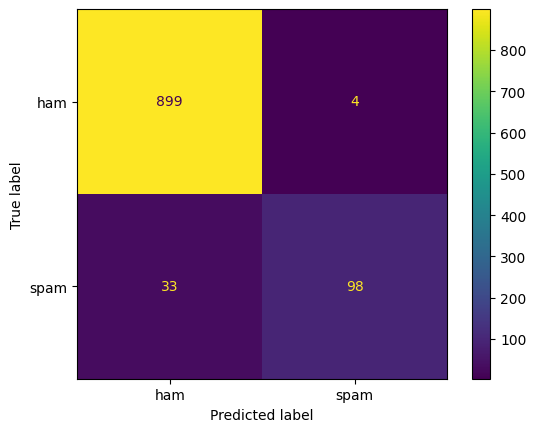

In [121]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])

print("cm:",cm)
print("_________")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham", "spam"]
)

disp.plot()
plt.show()

In [122]:
vectorizer_ngram = TfidfVectorizer(
    ngram_range=(1, 2)
)

In [123]:
X_train_ngram = vectorizer_ngram.fit_transform(X_train)

X_test_ngram = vectorizer_ngram.transform(X_test)

In [124]:
model_ngram = LogisticRegression()

model_ngram.fit(X_train_ngram, y_train)

y_pred_ngram = model_ngram.predict(X_test_ngram)

In [125]:
print("Training shape:", X_train_ngram.shape)
print("Test shape:", X_test_ngram.shape)

Training shape: (4135, 42642)
Test shape: (1034, 42642)


In [126]:
accuracy_ngram = accuracy_score(y_test, y_pred_ngram)

print("N-Gram Model Accuracy:", accuracy_ngram)
print()
print(classification_report(y_test, y_pred_ngram))

N-Gram Model Accuracy: 0.9593810444874274

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       1.00      0.68      0.81       131

    accuracy                           0.96      1034
   macro avg       0.98      0.84      0.89      1034
weighted avg       0.96      0.96      0.96      1034



In [127]:
def create_message_features(messages):
    features = pd.DataFrame(index=messages.index)

    features["message_length"] = messages.str.len()
    features["digit_count"] = messages.str.count(r"\d")
    features["exclamation_count"] = messages.str.count("!")
    features["uppercase_count"] = messages.apply(
        lambda x: sum(char.isupper() for char in x)
    )

    return features

In [128]:
train_features = create_message_features(X_train)
test_features = create_message_features(X_test)

In [129]:
print(train_features.head())
print()
print(train_features.shape)
print(test_features.shape)

      message_length  digit_count  exclamation_count  uppercase_count
336               45            0                  1                3
390               47            0                  0                2
582               46            0                  0                1
1387              27            1                  0                1
1095              71            0                  0                3

(4135, 4)
(1034, 4)


In [130]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_features_scaled = scaler.fit_transform(train_features)
test_features_scaled = scaler.transform(test_features)

print(train_features_scaled.shape)
print(test_features_scaled.shape)

(4135, 4)
(1034, 4)


In [131]:
from scipy.sparse import hstack

X_train_combined = hstack([
    X_train_tfidf,
    train_features_scaled
])

X_test_combined = hstack([
    X_test_tfidf,
    test_features_scaled
])

print("Combined training shape:", X_train_combined.shape)
print("Combined test shape:", X_test_combined.shape)

Combined training shape: (4135, 7684)
Combined test shape: (1034, 7684)


In [132]:
model_combined = LogisticRegression()

model_combined.fit(X_train_combined, y_train)

y_pred_combined = model_combined.predict(X_test_combined)

In [133]:
accuracy_combined = accuracy_score(y_test, y_pred_combined)

print("Combined Model Accuracy:", accuracy_combined)
print()
print(classification_report(y_test, y_pred_combined))

Combined Model Accuracy: 0.9816247582205029

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.98      0.87      0.92       131

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.96      1034
weighted avg       0.98      0.98      0.98      1034



cm: [[901   2]
 [ 17 114]]
_________


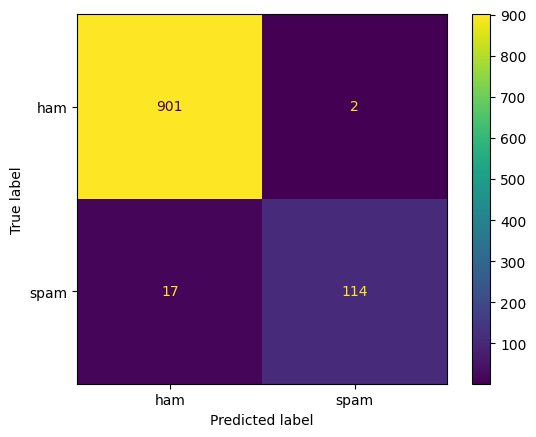

In [134]:
cm_combined = confusion_matrix(y_test, y_pred_combined, labels=["ham", "spam"])

print("cm:",cm_combined)
print("_________")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_combined,
    display_labels=["ham", "spam"]
)

disp.plot()
plt.show()

In [135]:
error_analysis = pd.DataFrame({
    "message": X_test,
    "actual": y_test,
    "predicted": y_pred_combined
})

errors = error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
]

print("Number of errors:", len(errors))
print(errors)

Number of errors: 19
                                                message actual predicted
1507  Thanks for the Vote. Now sing along with the s...   spam       ham
529   You will recieve your tone within the next 24h...   spam       ham
1470  7 wonders in My WORLD 7th You 6th Ur style 5th...    ham      spam
5098  TheMob>Hit the link to get a premium Pink Pant...   spam       ham
1460  Bought one ringtone and now getting texts cost...   spam       ham
2402  Babe: U want me dont u baby! Im nasty and have...   spam       ham
4821  Check Out Choose Your Babe Videos @ sms.shsex....   spam       ham
4144  In The Simpsons Movie released in July 2007 na...   spam       ham
4870  1. Tension face 2. Smiling face 3. Waste face ...    ham      spam
788   Ever thought about living a good life with a p...   spam       ham
4394  RECPT 1/3. You have ordered a Ringtone. Your o...   spam       ham
3530  Xmas & New Years Eve tickets are now on sale f...   spam       ham
5449  Latest News! Police stat

In [136]:
false_positives = errors[
    (errors["actual"] == "ham") &
    (errors["predicted"] == "spam")
]

false_negatives = errors[
    (errors["actual"] == "spam") &
    (errors["predicted"] == "ham")
]

print("False Positives (ham → spam):")
print(false_positives[["message", "actual", "predicted"]])

print("\nFalse Negatives (spam → ham):")
print(false_negatives[["message", "actual", "predicted"]])

False Positives (ham → spam):
                                                message actual predicted
1470  7 wonders in My WORLD 7th You 6th Ur style 5th...    ham      spam
4870  1. Tension face 2. Smiling face 3. Waste face ...    ham      spam

False Negatives (spam → ham):
                                                message actual predicted
1507  Thanks for the Vote. Now sing along with the s...   spam       ham
529   You will recieve your tone within the next 24h...   spam       ham
5098  TheMob>Hit the link to get a premium Pink Pant...   spam       ham
1460  Bought one ringtone and now getting texts cost...   spam       ham
2402  Babe: U want me dont u baby! Im nasty and have...   spam       ham
4821  Check Out Choose Your Babe Videos @ sms.shsex....   spam       ham
4144  In The Simpsons Movie released in July 2007 na...   spam       ham
788   Ever thought about living a good life with a p...   spam       ham
4394  RECPT 1/3. You have ordered a Ringtone. Your o...   spam 

In [137]:
char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5)
)

X_train_char = char_vectorizer.fit_transform(X_train)
X_test_char = char_vectorizer.transform(X_test)

print("Character TF-IDF training shape:", X_train_char.shape)
print("Character TF-IDF test shape:", X_test_char.shape)

Character TF-IDF training shape: (4135, 135058)
Character TF-IDF test shape: (1034, 135058)


In [138]:
char_model = LogisticRegression()

char_model.fit(X_train_char, y_train)

y_pred_char = char_model.predict(X_test_char)

In [139]:
accuracy_char = accuracy_score(y_test, y_pred_char)

print("Character TF-IDF Accuracy:", accuracy_char)
print()
print(classification_report(y_test, y_pred_char))

Character TF-IDF Accuracy: 0.9748549323017408

              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       903
        spam       1.00      0.80      0.89       131

    accuracy                           0.97      1034
   macro avg       0.99      0.90      0.94      1034
weighted avg       0.98      0.97      0.97      1034



In [140]:
y_prob = model_combined.predict_proba(X_test_combined)[:, 1]

print(y_prob[:10])

[0.01226582 0.00872774 0.02189987 0.0277233  0.00998719 0.01935204
 0.03349594 0.0021615  0.01031174 0.00755193]


In [141]:
from sklearn.metrics import precision_score, recall_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    # Convert model's string labels to 0/1
    y_test_binary = (y_test == "spam").astype(int)

    precision = precision_score(y_test_binary, y_pred_threshold)
    recall = recall_score(y_test_binary, y_pred_threshold)

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f}"
    )

Threshold: 0.3 | Precision: 0.97 | Recall: 0.89
Threshold: 0.4 | Precision: 0.98 | Recall: 0.88
Threshold: 0.5 | Precision: 0.98 | Recall: 0.87
Threshold: 0.6 | Precision: 1.00 | Recall: 0.85
Threshold: 0.7 | Precision: 1.00 | Recall: 0.83


In [142]:
import joblib

joblib.dump(model_combined, "../models/spam_model.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")
joblib.dump(scaler, "../models/feature_scaler.pkl")

print("Models saved successfully!")

Models saved successfully!


In [143]:
import pandas as pd

feature_names = vectorizer.get_feature_names_out()

tfidf_coefficients = model_combined.coef_[0][:len(feature_names)]

feature_weights = pd.DataFrame({
    "feature": feature_names,
    "weight": tfidf_coefficients
})

spam_features = feature_weights.sort_values(
    "weight",
    ascending=False
)

print("Top 20 TF-IDF features associated with spam:")
print(spam_features.head(20))

Top 20 TF-IDF features associated with spam:
       feature    weight
7649      your  2.498555
6728      text  2.167961
2936      free  2.159648
4498    mobile  2.048106
5666     reply  1.992602
7058        uk  1.867058
7578       www  1.646992
1968   content  1.528158
1891       com  1.502116
1862        co  1.466794
2895       for  1.458505
5973   service  1.363657
3489      http  1.294627
5741  ringtone  1.279256
2975      from  1.185580
6871        to  1.168122
4702       new  1.159401
4409   message  1.078958
6436      stop  1.067322
7030       txt  1.058087


In [144]:
engineered_feature_names = [
    "message_length",
    "digit_count",
    "exclamation_count",
    "uppercase_count"
]

engineered_weights = model_combined.coef_[0][-4:]

for feature, weight in zip(
    engineered_feature_names,
    engineered_weights
):
    print(f"{feature}: {weight:.4f}")

message_length: 0.2936
digit_count: 3.0210
exclamation_count: 0.1763
uppercase_count: 0.0825


In [145]:
char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(2, 5)
)

X_train_char = char_vectorizer.fit_transform(X_train)
X_test_char = char_vectorizer.transform(X_test)

print("Character TF-IDF train shape:", X_train_char.shape)
print("Character TF-IDF test shape:", X_test_char.shape)

Character TF-IDF train shape: (4135, 135058)
Character TF-IDF test shape: (1034, 135058)


In [146]:
from scipy.sparse import hstack

X_train_all = hstack([
    X_train_tfidf,
    X_train_char,
    train_features_scaled
])

X_test_all = hstack([
    X_test_tfidf,
    X_test_char,
    test_features_scaled
])

print("Combined train shape:", X_train_all.shape)
print("Combined test shape:", X_test_all.shape)

Combined train shape: (4135, 142742)
Combined test shape: (1034, 142742)


In [147]:
from sklearn.linear_model import LogisticRegression

model_all = LogisticRegression()

model_all.fit(X_train_all, y_train)

y_pred_all = model_all.predict(X_test_all)

In [148]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_all = accuracy_score(y_test, y_pred_all)

print("Accuracy:", accuracy_all)
print()
print(classification_report(y_test, y_pred_all))

Accuracy: 0.9845261121856866

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.99      0.89      0.94       131

    accuracy                           0.98      1034
   macro avg       0.99      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



[[902   1]
 [ 15 116]]


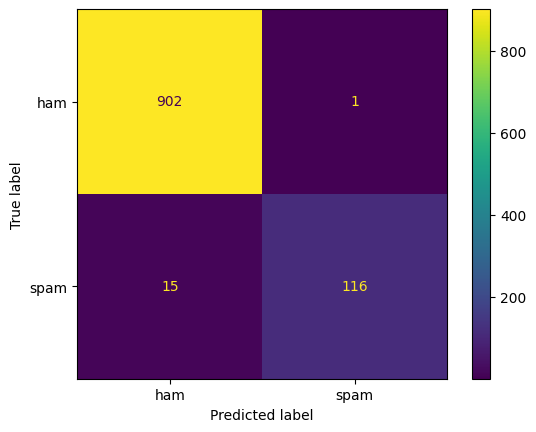

In [149]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_all = confusion_matrix(
    y_test,
    y_pred_all,
    labels=["ham", "spam"]
)

print(cm_all)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_all,
    display_labels=["ham", "spam"]
)

disp.plot()
plt.show()

In [150]:
error_analysis_all = pd.DataFrame({
    "message": X_test,
    "actual": y_test,
    "predicted": y_pred_all
})

false_negatives_all = error_analysis_all[
    (error_analysis_all["actual"] == "spam") &
    (error_analysis_all["predicted"] == "ham")
]

print("False negatives:", len(false_negatives_all))
print()

for i, message in enumerate(false_negatives_all["message"], start=1):
    print(f"{i}. {message}")
    print()

False negatives: 15

1. Thanks for the Vote. Now sing along with the stars with Karaoke on your mobile. For a FREE link just reply with SING now.

2. TheMob>Hit the link to get a premium Pink Panther game, the new no. 1 from Sugababes, a crazy Zebra animation or a badass Hoody wallpaper-all 4 FREE!

3. Bought one ringtone and now getting texts costing 3 pound offering more tones etc

4. Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about we go slo n hard! Txt XXX SLO(4msgs)

5. Check Out Choose Your Babe Videos @ sms.shsex.netUN fgkslpoPW fgkslpo

6. In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day, B-Blue Day, C-Red Day. (Send A, B or C)

7. Ever thought about living a good life with a perfect partner? Just txt back NAME and AGE to join the mobile community. (100p/SMS)

8. RECPT 1/3. You have ordered a Ringtone. Your order is being processed...

9. Xmas & New Years 

In [151]:
false_negative_messages = false_negatives_all["message"]

false_negative_tfidf = vectorizer.transform(false_negative_messages)
false_negative_char = char_vectorizer.transform(false_negative_messages)

false_negative_features = create_message_features(
    false_negative_messages
)

false_negative_features_scaled = scaler.transform(
    false_negative_features
)

false_negative_combined = hstack([
    false_negative_tfidf,
    false_negative_char,
    false_negative_features_scaled
])

false_negative_probabilities = (
    model_all.predict_proba(false_negative_combined)[:, 1]
)

false_negative_analysis = pd.DataFrame({
    "message": false_negative_messages,
    "spam_probability": false_negative_probabilities
})

false_negative_analysis = false_negative_analysis.sort_values(
    "spam_probability"
)

for _, row in false_negative_analysis.iterrows():
    print(f"{row['spam_probability']:.2%} | {row['message']}")
    print()

1.89% | Would you like to see my XXX pics they are so hot they were nearly banned in the uk!

2.66% | Latest News! Police station toilet stolen, cops have nothing to go on!

5.84% | Check Out Choose Your Babe Videos @ sms.shsex.netUN fgkslpoPW fgkslpo

7.22% | Burger King - Wanna play footy at a top stadium? Get 2 Burger King before 1st Sept and go Large or Super with Coca-Cola and walk out a winner

8.10% | Bought one ringtone and now getting texts costing 3 pound offering more tones etc

9.48% | Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about we go slo n hard! Txt XXX SLO(4msgs)

9.99% | In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day, B-Blue Day, C-Red Day. (Send A, B or C)

13.78% | ringtoneking 84484

16.09% | RECPT 1/3. You have ordered a Ringtone. Your order is being processed...

22.22% | Thanks for the Vote. Now sing along with the stars with Karaoke on

In [152]:
message_to_explain = false_negative_analysis.iloc[0]["message"]

print(message_to_explain)

Would you like to see my XXX pics they are so hot they were nearly banned in the uk!


In [153]:
message_tfidf = vectorizer.transform(
    pd.Series([message_to_explain])
)

message_char = char_vectorizer.transform(
    pd.Series([message_to_explain])
)

message_features = create_message_features(
    pd.Series([message_to_explain])
)

message_features_scaled = scaler.transform(message_features)

message_combined = hstack([
    message_tfidf,
    message_char,
    message_features_scaled
])

print("Prediction:", model_all.predict(message_combined)[0])
print("Spam probability:", model_all.predict_proba(message_combined)[0][1])

Prediction: ham
Spam probability: 0.018884878294694048


In [154]:
# Word-level feature contributions
word_feature_names = vectorizer.get_feature_names_out()
word_values = message_tfidf.toarray()[0]

word_weights = model_all.coef_[0][:len(word_feature_names)]

word_contributions = word_values * word_weights

word_contribution_df = pd.DataFrame({
    "feature": word_feature_names,
    "contribution": word_contributions
})

# Show features pushing toward spam
print("Top features pushing toward SPAM:")
print(
    word_contribution_df
    .sort_values("contribution", ascending=False)
    .head(10)
)

print()

# Show features pushing toward ham
print("Top features pushing toward HAM:")
print(
    word_contribution_df
    .sort_values("contribution", ascending=True)
    .head(10)
)

Top features pushing toward SPAM:
     feature  contribution
7058      uk      0.354633
6871      to      0.088425
3463     hot      0.061340
6756     the      0.034023
7644     you      0.021801
7594     xxx      0.013568
1034     are      0.003418
7679     〨ud     -0.000000
0         00      0.000000
1        000      0.000000

Top features pushing toward HAM:
     feature  contribution
4613      my     -0.198617
3596      in     -0.069766
6227      so     -0.064140
4067    like     -0.049139
7397    were     -0.040365
5930     see     -0.034278
6782    they     -0.034201
7547   would     -0.014344
5155    pics     -0.006355
4664  nearly     -0.003961


In [155]:
char_feature_names = char_vectorizer.get_feature_names_out()

char_values = message_char.toarray()[0]

# Character features come after all word features
char_weights = model_all.coef_[0][
    len(word_feature_names):
    len(word_feature_names) + len(char_feature_names)
]

char_contributions = char_values * char_weights

char_contribution_df = pd.DataFrame({
    "feature": char_feature_names,
    "contribution": char_contributions
})

print("Top character features pushing toward SPAM:")
print(
    char_contribution_df
    .sort_values("contribution", ascending=False)
    .head(10)
)

print()

print("Top character features pushing toward HAM:")
print(
    char_contribution_df
    .sort_values("contribution", ascending=True)
    .head(10)
)

Top character features pushing toward SPAM:
       feature  contribution
88524       ne      0.020415
123520      uk      0.019113
105643      re      0.016894
10661        t      0.012173
98772       ou      0.011470
81752       ly      0.010403
51260     e ne      0.009642
10096       se      0.009312
54162      ee       0.008318
119845      to      0.008186

Top character features pushing toward HAM:
       feature  contribution
66012       he     -0.015044
131018      y      -0.012687
85602      my      -0.011534
85601       my     -0.010337
8326       my      -0.009835
8325        my     -0.009367
66653      hey     -0.008902
6504         i     -0.007948
113376      so     -0.007402
105644     re      -0.007054


In [156]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    class_weight="balanced"
)

balanced_model.fit(X_train_all, y_train)

y_pred_balanced = balanced_model.predict(X_test_all)

In [157]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_balanced = accuracy_score(
    y_test,
    y_pred_balanced
)

print("Accuracy:", accuracy_balanced)
print()
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.9874274661508704

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       903
        spam       0.97      0.93      0.95       131

    accuracy                           0.99      1034
   macro avg       0.98      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034



[[899   4]
 [  9 122]]


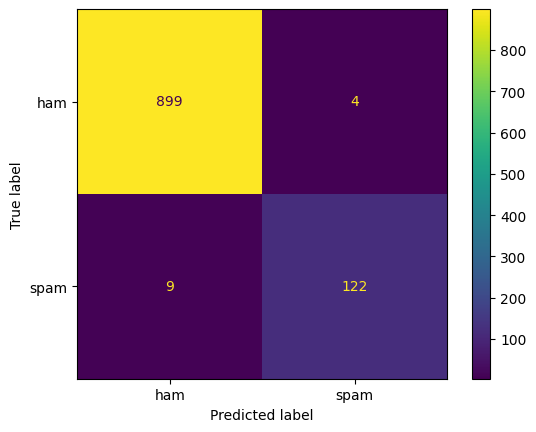

In [158]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_balanced = confusion_matrix(
    y_test,
    y_pred_balanced,
    labels=["ham", "spam"]
)

print(cm_balanced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=["ham", "spam"]
)

disp.plot()
plt.show()

In [159]:
comparison = pd.DataFrame({
    "message": X_test,
    "actual": y_test,
    "old_prediction": model_all.predict(X_test_all),
    "balanced_prediction": balanced_model.predict(X_test_all)
})

changed_predictions = comparison[
    comparison["old_prediction"] != comparison["balanced_prediction"]
]

print("Number of changed predictions:", len(changed_predictions))
print()

for _, row in changed_predictions.iterrows():
    print("Message:", row["message"])
    print("Actual:", row["actual"])
    print("Old prediction:", row["old_prediction"])
    print("Balanced prediction:", row["balanced_prediction"])
    print("-" * 80)

Number of changed predictions: 9

Message: Thanks for the Vote. Now sing along with the stars with Karaoke on your mobile. For a FREE link just reply with SING now.
Actual: spam
Old prediction: ham
Balanced prediction: spam
--------------------------------------------------------------------------------
Message: TheMob>Hit the link to get a premium Pink Panther game, the new no. 1 from Sugababes, a crazy Zebra animation or a badass Hoody wallpaper-all 4 FREE!
Actual: spam
Old prediction: ham
Balanced prediction: spam
--------------------------------------------------------------------------------
Message: Dunno da next show aft 6 is 850. Toa payoh got 650.
Actual: ham
Old prediction: ham
Balanced prediction: spam
--------------------------------------------------------------------------------
Message: 1. Tension face 2. Smiling face 3. Waste face 4. Innocent face 5.Terror face 6.Cruel face 7.Romantic face 8.Lovable face 9.decent face  &lt;#&gt; .joker face.
Actual: ham
Old prediction: 

In [160]:
balanced_error_analysis = pd.DataFrame({
    "message": X_test,
    "actual": y_test,
    "predicted": y_pred_balanced
})

balanced_false_negatives = balanced_error_analysis[
    (balanced_error_analysis["actual"] == "spam") &
    (balanced_error_analysis["predicted"] == "ham")
]

print("Remaining false negatives:", len(balanced_false_negatives))
print()

for i, message in enumerate(
    balanced_false_negatives["message"],
    start=1
):
    print(f"{i}. {message}")
    print()

Remaining false negatives: 9

1. Bought one ringtone and now getting texts costing 3 pound offering more tones etc

2. Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about we go slo n hard! Txt XXX SLO(4msgs)

3. Check Out Choose Your Babe Videos @ sms.shsex.netUN fgkslpoPW fgkslpo

4. In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day, B-Blue Day, C-Red Day. (Send A, B or C)

5. RECPT 1/3. You have ordered a Ringtone. Your order is being processed...

6. Latest News! Police station toilet stolen, cops have nothing to go on!

7. Would you like to see my XXX pics they are so hot they were nearly banned in the uk!

8. ringtoneking 84484

9. Burger King - Wanna play footy at a top stadium? Get 2 Burger King before 1st Sept and go Large or Super with Coca-Cola and walk out a winner



In [161]:
improved_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

In [162]:
X_train_improved = improved_vectorizer.fit_transform(X_train)
X_test_improved = improved_vectorizer.transform(X_test)

print("Train shape:", X_train_improved.shape)
print("Test shape:", X_test_improved.shape)

Train shape: (4135, 10188)
Test shape: (1034, 10188)


In [163]:
X_train_improved_all = hstack([
    X_train_improved,
    X_train_char,
    train_features_scaled
])

X_test_improved_all = hstack([
    X_test_improved,
    X_test_char,
    test_features_scaled
])

print("Combined train shape:", X_train_improved_all.shape)
print("Combined test shape:", X_test_improved_all.shape)

Combined train shape: (4135, 145250)
Combined test shape: (1034, 145250)


In [164]:
improved_balanced_model = LogisticRegression(
    class_weight="balanced"
)

improved_balanced_model.fit(
    X_train_improved_all,
    y_train
)

y_pred_improved = improved_balanced_model.predict(
    X_test_improved_all
)

In [165]:
accuracy_improved = accuracy_score(
    y_test,
    y_pred_improved
)

print("Accuracy:", accuracy_improved)
print()
print(
    classification_report(
        y_test,
        y_pred_improved
    )
)

Accuracy: 0.9864603481624759

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.96      0.93      0.95       131

    accuracy                           0.99      1034
   macro avg       0.98      0.96      0.97      1034
weighted avg       0.99      0.99      0.99      1034



In [166]:
cm_improved = confusion_matrix(
    y_test,
    y_pred_improved,
    labels=["ham", "spam"]
)

print(cm_improved)

[[898   5]
 [  9 122]]


In [167]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

C_values = [0.01, 0.1, 0.5, 1, 2, 5, 10]

results = []

for C in C_values:

    model_c = LogisticRegression(
        C=C,
        class_weight="balanced"
    )

    model_c.fit(
        X_train_all,
        y_train
    )

    predictions = model_c.predict(
        X_test_all
    )

    results.append({
        "C": C,
        "accuracy": accuracy_score(y_test, predictions),
        "spam_precision": precision_score(
            y_test,
            predictions,
            pos_label="spam"
        ),
        "spam_recall": recall_score(
            y_test,
            predictions,
            pos_label="spam"
        ),
        "spam_f1": f1_score(
            y_test,
            predictions,
            pos_label="spam"
        )
    })

results_df = pd.DataFrame(results)

print(results_df)

       C  accuracy  spam_precision  spam_recall   spam_f1
0   0.01  0.966151        0.852941     0.885496  0.868914
1   0.10  0.976789        0.902256     0.916031  0.909091
2   0.50  0.985493        0.960317     0.923664  0.941634
3   1.00  0.987427        0.968254     0.931298  0.949416
4   2.00  0.988395        0.976000     0.931298  0.953125
5   5.00  0.990329        0.991870     0.931298  0.960630
6  10.00  0.991296        0.991935     0.938931  0.964706


In [168]:
C_values_fine = [5, 10, 20, 50]

results_fine = []

for C in C_values_fine:
    model_c = LogisticRegression(
        C=C,
        class_weight="balanced"
    )

    model_c.fit(X_train_all, y_train)
    predictions = model_c.predict(X_test_all)

    results_fine.append({
        "C": C,
        "accuracy": accuracy_score(y_test, predictions),
        "spam_precision": precision_score(
            y_test, predictions, pos_label="spam"
        ),
        "spam_recall": recall_score(
            y_test, predictions, pos_label="spam"
        ),
        "spam_f1": f1_score(
            y_test, predictions, pos_label="spam"
        )
    })

results_fine_df = pd.DataFrame(results_fine)

print(results_fine_df)

    C  accuracy  spam_precision  spam_recall   spam_f1
0   5  0.990329        0.991870     0.931298  0.960630
1  10  0.991296        0.991935     0.938931  0.964706
2  20  0.992263        1.000000     0.938931  0.968504
3  50  0.992263        1.000000     0.938931  0.968504


In [169]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression

cv_model = LogisticRegression(
    C=20,
    class_weight="balanced"
)

cv_results = cross_validate(
    cv_model,
    X_train_all,
    y_train,
    cv=5,
    scoring=[
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro"
    ],
    n_jobs=-1
)

print("Accuracy:", cv_results["test_accuracy"])
print("Mean accuracy:", cv_results["test_accuracy"].mean())

print("Macro precision:", cv_results["test_precision_macro"].mean())
print("Macro recall:", cv_results["test_recall_macro"].mean())
print("Macro F1:", cv_results["test_f1_macro"].mean())

Accuracy: [0.9758162  0.99032648 0.97944377 0.98548972 0.9879081 ]
Mean accuracy: 0.9837968561064085
Macro precision: 0.9725389629359904
Macro recall: 0.9529819899548121
Macro F1: 0.9623770218564202


In [170]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

In [171]:
class MessageFeatures(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = pd.DataFrame(index=X.index)

        features["message_length"] = X.str.len()
        features["digit_count"] = X.str.count(r"\d")
        features["exclamation_count"] = X.str.count("!")
        features["uppercase_count"] = X.apply(
            lambda x: sum(char.isupper() for char in x)
        )

        return features

In [172]:
from scipy.sparse import hstack

class CombinedFeatures(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.word_vectorizer = TfidfVectorizer()
        self.char_vectorizer = TfidfVectorizer(
            analyzer="char",
            ngram_range=(2, 5)
        )
        self.scaler = StandardScaler()

    def fit(self, X, y=None):
        word_features = self.word_vectorizer.fit_transform(X)
        char_features = self.char_vectorizer.fit_transform(X)

        engineered = MessageFeatures().transform(X)
        self.scaler.fit(engineered)

        return self

    def transform(self, X):
        word_features = self.word_vectorizer.transform(X)
        char_features = self.char_vectorizer.transform(X)

        engineered = MessageFeatures().transform(X)
        engineered_scaled = self.scaler.transform(engineered)

        return hstack([
            word_features,
            char_features,
            engineered_scaled
        ])

In [173]:
pipeline = Pipeline([
    ("features", CombinedFeatures()),
    ("model", LogisticRegression(
        C=20,
        class_weight="balanced"
    ))
])

In [174]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro"
    ],
    n_jobs=-1
)

print("Accuracy:", cv_results["test_accuracy"])
print("Mean accuracy:", cv_results["test_accuracy"].mean())

print("Macro precision:", cv_results["test_precision_macro"].mean())
print("Macro recall:", cv_results["test_recall_macro"].mean())
print("Macro F1:", cv_results["test_f1_macro"].mean())

Accuracy: [0.98307134 0.98428053 0.9879081  0.98669891 0.99032648]
Mean accuracy: 0.9864570737605804
Macro precision: 0.9771686862483451
Macro recall: 0.9610524138011467
Macro F1: 0.9686866939806891


In [175]:
C_values = [10, 20, 50]

cv_comparison = []

for C in C_values:

    pipeline = Pipeline([
        ("features", CombinedFeatures()),
        ("model", LogisticRegression(
            C=C,
            class_weight="balanced"
        ))
    ])

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision_macro",
            "recall_macro",
            "f1_macro"
        ],
        n_jobs=-1
    )

    cv_comparison.append({
        "C": C,
        "accuracy_mean": cv_results["test_accuracy"].mean(),
        "accuracy_std": cv_results["test_accuracy"].std(),
        "precision_mean": cv_results["test_precision_macro"].mean(),
        "recall_mean": cv_results["test_recall_macro"].mean(),
        "f1_mean": cv_results["test_f1_macro"].mean()
    })

cv_comparison_df = pd.DataFrame(cv_comparison)

print(cv_comparison_df)

    C  accuracy_mean  accuracy_std  precision_mean  recall_mean   f1_mean
0  10       0.985973      0.003116        0.975145     0.960776  0.967618
1  20       0.986457      0.002582        0.977169     0.961052  0.968687
2  50       0.987183      0.002715        0.980759     0.960654  0.970235


In [176]:
final_pipeline = Pipeline([
    ("features", CombinedFeatures()),
    ("model", LogisticRegression(
        C=50,
        class_weight="balanced"
    ))
])

In [177]:
final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",50
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: 

In [178]:
final_predictions = final_pipeline.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Final accuracy:")
print(accuracy_score(y_test, final_predictions))

print()
print("Classification report:")
print(classification_report(y_test, final_predictions))

Final accuracy:
0.9922630560928434

Classification report:
              precision    recall  f1-score   support

         ham       0.99      1.00      1.00       903
        spam       1.00      0.94      0.97       131

    accuracy                           0.99      1034
   macro avg       1.00      0.97      0.98      1034
weighted avg       0.99      0.99      0.99      1034



Confusion matrix:
[[903   0]
 [  8 123]]


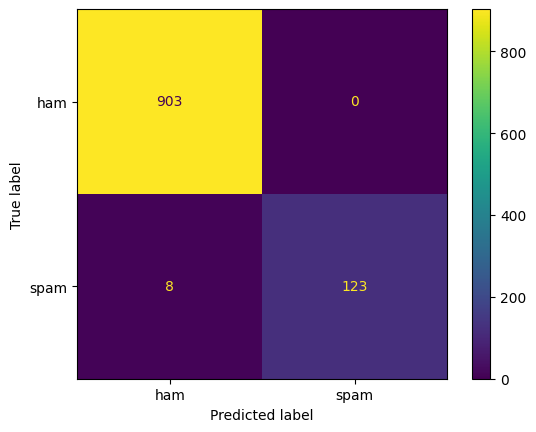

In [179]:
cm = confusion_matrix(
    y_test,
    final_predictions,
    labels=["ham", "spam"]
)

print("Confusion matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ham", "spam"]
)

disp.plot()
plt.show()

In [180]:
import joblib

joblib.dump(
    final_pipeline,
    "../models/final_spam_pipeline.pkl"
)

print("Final pipeline saved successfully!")

Final pipeline saved successfully!


In [183]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

print(project_root)

c:\Users\HARSHA\Desktop\My Projects\spam-classifier


In [184]:
from src.preprocessing import CombinedFeatures

print("CombinedFeatures imported successfully!")

CombinedFeatures imported successfully!


In [185]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import joblib

final_pipeline = Pipeline([
    ("features", CombinedFeatures()),
    ("model", LogisticRegression(
        C=50,
        class_weight="balanced"
    ))
])

In [186]:
final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",50
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: 

In [187]:
joblib.dump(
    final_pipeline,
    "../models/final_spam_pipeline.pkl"
)

print("Final pipeline rebuilt and saved successfully!")

Final pipeline rebuilt and saved successfully!
